# **Hybrid CNN-BiGRU with Self-Attention for Speech Emotion Recognition Using MFCC and Mel Spectrogram Features**

### **Members**
- Geverola, Lady Jean Y.
- Valdez, Adrienne Jill B.

### **Course and Section**
DS 175 – Deep Neural Networks  
Bachelor of Science in Data Science

### **Brief Project Description**
This project focuses on Speech Emotion Recognition (SER) using a Hybrid CNN-BiGRU with Self-Attention deep learning architecture. The model utilizes MFCC and Mel Spectrogram features extracted from speech audio recordings in the RAVDESS dataset. CNN layers are used for acoustic feature extraction, BiGRU captures temporal dependencies in speech signals, and the Self-Attention mechanism helps the model focus on emotionally important speech segments. Data augmentation techniques are also applied to improve model generalization and classification performance.

# **Problem Statement**

### **Problem/Task Definition**
Speech Emotion Recognition (SER) is a deep learning task that aims to automatically identify human emotions from speech signals. Recognizing emotions from audio is challenging because emotions vary in tone, pitch, speaking style, intensity, and pronunciation. This project aims to develop a Hybrid CNN-BiGRU with Self-Attention model capable of classifying emotions from speech audio recordings using MFCC and Mel Spectrogram features.

### **Importance of the Task**
Speech Emotion Recognition is important in many real-world applications such as virtual assistants, customer service systems, healthcare monitoring, intelligent tutoring systems, and human-computer interaction. Accurate emotion recognition can improve communication between humans and intelligent systems by enabling systems to better understand emotional states and respond more effectively.

### **Expected Output of the Model**
The expected output of the model is the predicted emotion label of a speech audio recording. The model will classify speech into one of the following emotion classes:

- Neutral
- Calm
- Happy
- Sad
- Angry
- Fearful
- Disgust
- Surprised

# **Dataset Loading and Exploration**

This section focuses on loading the RAVDESS Speech Emotion Recognition dataset, exploring its structure, visualizing class distributions, and displaying sample audio signals. Exploratory analysis helps in understanding the dataset before preprocessing and model training.

###IMPORT REQUIRED LIBRARIES

In [ ]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# File and directory handling
import os

# Audio processing
import librosa
import librosa.display

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Download Kaggle datasets
import kagglehub

# Deep learning framework
import tensorflow as tf

###DOWNLOAD THE RAVDESS DATASET

In [ ]:
# Download dataset from Kaggle
path = kagglehub.dataset_download(
    "uwrfkaggler/ravdess-emotional-speech-audio"
)

# Display dataset location
print("Dataset Path:", path)

100%|██████████| 429M/429M [00:06<00:00, 69.3MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1


##Emotion Labels Used in the Dataset

| Emotion Code | Emotion Label |
|--------------|---------------|
| 01 | Neutral |
| 02 | Calm |
| 03 | Happy |
| 04 | Sad |
| 05 | Angry |
| 06 | Fearful |
| 07 | Disgust |
| 08 | Surprised |

###MAP EMOTION CODES TO EMOTION LABELS

In [ ]:
# Dictionary for converting emotion codes
# into readable emotion labels

emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

##**Display Sample Audio Waveform**

The following visualization shows a sample speech waveform from the RAVDESS dataset. Waveforms represent the variation of audio amplitude over time and provide insight into speech signal patterns.

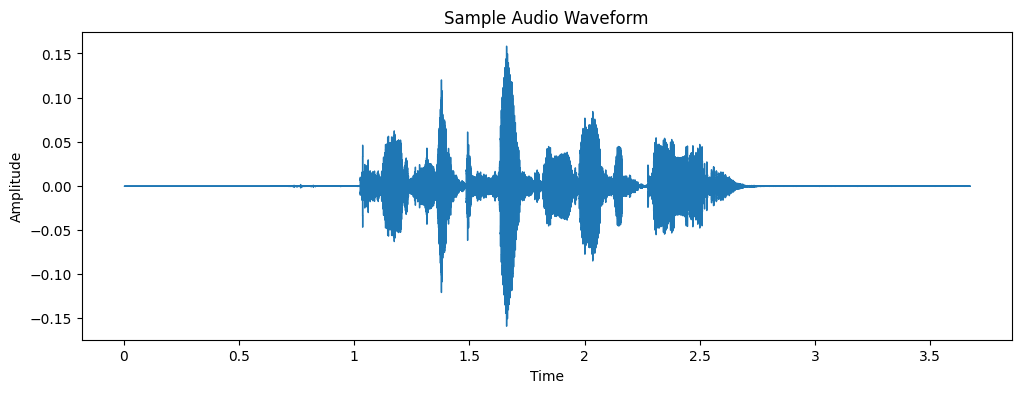

In [ ]:
# DISPLAY SAMPLE AUDIO WAVEFORM

# Create a variable that will store the path
# of the first sample audio file found in the dataset
sample_file = None

# Traverse all folders and subfolders inside the dataset directory
# os.walk() iterates through:
# - root  -> current folder path
# - dirs  -> subfolders inside the current folder
# - files -> files inside the current folder
for root, dirs, files in os.walk(path):

    # Iterate through all files inside the current folder
    for file in files:

        # Check whether the current file is a WAV audio file
        # Only .wav files are processed because the dataset
        # consists of speech audio recordings
        if file.endswith(".wav"):

            # Construct the complete file path
            # by combining the folder path and filename
            sample_file = os.path.join(root, file)

            # Stop searching once the first audio file is found
            break

    # Exit the outer loop once a sample file is already stored
    if sample_file:
        break

# Load the selected audio file using librosa
# audio -> stores the audio waveform signal values
# sr    -> stores the sampling rate of the audio
audio, sr = librosa.load(sample_file)

# Create a plotting figure
# figsize controls the width and height of the graph
plt.figure(figsize=(12, 4))

# Display the waveform of the audio signal
# waveshow() visualizes amplitude changes over time
# sr ensures the waveform uses the correct time scale
librosa.display.waveshow(audio, sr=sr)

# Add title to the graph
plt.title("Sample Audio Waveform")

# Label the x-axis as Time
# since the horizontal axis represents audio duration
plt.xlabel("Time")

# Label the y-axis as Amplitude
# since the vertical axis represents signal intensity
plt.ylabel("Amplitude")

# Display the final waveform plot
plt.show()

####**Sample Audio Waveform Interpretation**: The waveform represents the variation of the speech signal’s amplitude over time. Higher peaks indicate stronger or louder speech segments, while flatter regions represent silence or low-intensity audio. The waveform visualization helps analyze speech activity and provides an initial understanding of the audio signal patterns used for Speech Emotion Recognition.

##**Dataset Statistics and Class Distribution**

The following visualization shows the distribution of emotion classes in the dataset. Understanding class balance is important because imbalanced datasets may affect model performance and prediction bias.

In [ ]:
# ANALYZE EMOTION CLASS DISTRIBUTION

# Create an empty list for storing
# all extracted emotion labels from the dataset
emotion_labels = []

# Traverse all folders and subfolders inside the dataset directory
# os.walk() iterates through:
# - root  -> current folder path
# - dirs  -> subfolders inside the folder
# - files -> files inside the folder
for root, dirs, files in os.walk(path):

    # Iterate through all files in the current folder
    for file in files:

        # Process only WAV audio files
        # since the dataset contains speech recordings
        if file.endswith(".wav"):

            # Extract the emotion code from the filename
            # Example filename format:
            # 03-01-05-01-01-01-01.wav
            #
            # Splitting by "-" gives:
            # ['03', '01', '05', '01', '01', '01', '01.wav']
            #
            # Index [2] corresponds to the emotion code
            emotion_code = file.split("-")[2]

            # Check whether the extracted emotion code
            # exists in the emotion mapping dictionary
            if emotion_code in emotion_map:

                # Convert the emotion code into its
                # corresponding emotion label
                # then append it into the emotion list
                emotion_labels.append(
                    emotion_map[emotion_code]
                )

# Convert the emotion label list into a Pandas DataFrame
# for easier analysis and visualization
emotion_df = pd.DataFrame(

    emotion_labels,

    columns=["Emotion"]
)

# Display the total number of samples
# for each emotion category
# value_counts() counts occurrences of each class
print(emotion_df["Emotion"].value_counts())

Emotion
angry        384
surprised    384
calm         384
fearful      384
happy        384
sad          384
disgust      384
neutral      192
Name: count, dtype: int64


## **Emotion Class Distribution Visualization**

The histogram below visualizes the number of speech samples for each emotion class in the dataset.

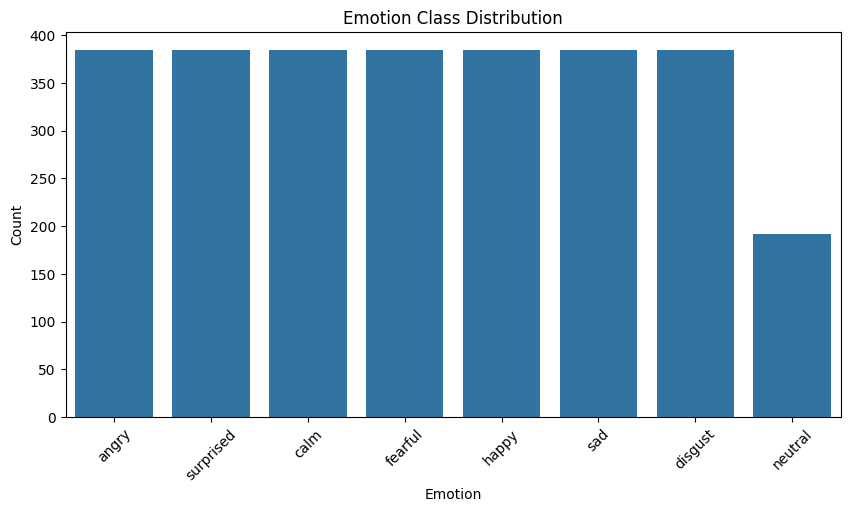

In [ ]:
# PLOT EMOTION CLASS DISTRIBUTION

# Create a plotting figure
# figsize controls the width and height of the graph
plt.figure(figsize=(10, 5))

# Create a count plot using Seaborn
# x="Emotion" specifies that emotion labels
# will be displayed along the x-axis
#
# data=emotion_df tells Seaborn to use
# the DataFrame containing emotion labels
#
# countplot() automatically counts the number
# of occurrences for each emotion category
sns.countplot(
    x="Emotion",
    data=emotion_df
)

# Add a title to the visualization
# to describe the graph content
plt.title("Emotion Class Distribution")

# Rotate x-axis labels by 45 degrees
# to improve readability and prevent overlap
plt.xticks(rotation=45)

# Label the x-axis
# representing the emotion categories
plt.xlabel("Emotion")

# Label the y-axis
# representing the number of samples
# for each emotion class
plt.ylabel("Count")

# Display the final visualization
plt.show()

##**Sample Time-Series Plot**

The following graph displays a time-series representation of a speech audio signal. This helps visualize how speech amplitudes change over time.

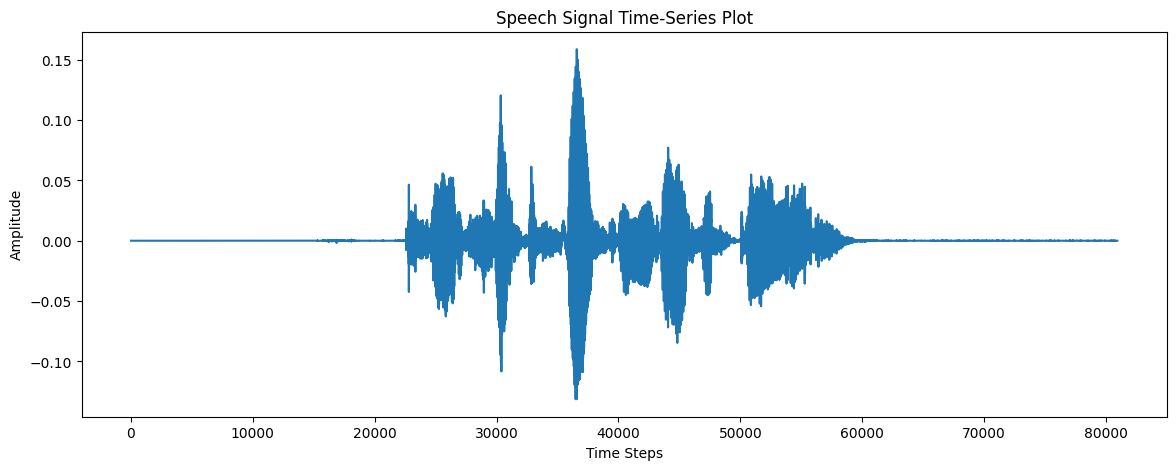

In [ ]:
# DISPLAY SAMPLE TIME-SERIES PLOT

# Create a plotting figure
# figsize controls the width and height of the graph
plt.figure(figsize=(14, 5))

# Plot the raw audio waveform signal
# plt.plot() visualizes how the audio amplitude
# changes over time
#
# The variable "audio" contains the numerical
# amplitude values of the speech signal
plt.plot(audio)

# Add a title to describe the visualization
plt.title("Speech Signal Time-Series Plot")

# Label the x-axis
# representing the time progression or time steps
# of the audio signal
plt.xlabel("Time Steps")

# Label the y-axis
# representing the amplitude or intensity
# of the speech signal
plt.ylabel("Amplitude")

# Display the final time-series graph
plt.show()

####**Speech Signal Time-Series Plot Interpretation**: The time-series plot shows how the speech signal amplitude changes across time steps. Regions with larger amplitudes represent stronger speech activity, while flatter regions indicate silence or low-intensity sound. This visualization helps analyze the temporal behavior of the audio signal and provides insight into the speech patterns used by the model for emotion recognition.

#**Data Preprocessing**

This section focuses on preprocessing the speech audio data before model training. The preprocessing stage includes data augmentation, feature extraction, normalization, label encoding, and train-test splitting. Proper preprocessing helps improve model performance, stability, and generalization.

##**Data Augmentation**

Data augmentation is applied to increase dataset diversity and improve model robustness. The following augmentation techniques are used:

- Noise Injection
- Pitch Shifting
- Time Stretching

These techniques help the model generalize better to unseen speech variations.

In [ ]:
# DATA AUGMENTATION FUNCTIONS

# Import NumPy library
# NumPy is used for numerical computations
# and generating random noise values
import numpy as np

# ADD RANDOM NOISE

# Function for adding random noise
# to the original audio signal
#
# Data augmentation helps increase
# dataset diversity and improves
# model generalization performance
def add_noise(data):

    # Generate random Gaussian noise
    #
    # np.random.randn() creates random values
    # with a normal distribution
    #
    # len(data) ensures that the generated
    # noise has the same length as the audio signal
    #
    # 0.005 controls the noise intensity
    noise = 0.005 * np.random.randn(len(data))

    # Add noise to the original audio signal
    # and return the augmented signal
    return data + noise

# APPLY PITCH SHIFTING

# Function for modifying the pitch
# of the audio signal
#
# Pitch shifting changes the frequency
# characteristics of speech while preserving
# the overall audio duration
def pitch_shift(data, sample_rate):

    # Shift pitch upward by 2 semitone steps
    #
    # data         -> original audio signal
    # sr           -> sampling rate
    # n_steps=2    -> number of pitch shift steps
    return librosa.effects.pitch_shift(
        data,
        sr=sample_rate,
        n_steps=2
    )

# APPLY TIME STRETCHING

# Function for stretching or compressing
# the duration of the audio signal
#
# Time stretching changes speech speed
# without significantly altering pitch
def time_stretch(data):

    # Stretch the audio signal
    #
    # rate=0.8 slows down the audio
    # making the speech duration longer
    return librosa.effects.time_stretch(
        data,
        rate=0.8
    )

## **Feature Extraction**

The project uses the following audio features:

- MFCC (Mel Frequency Cepstral Coefficients)
- Mel Spectrogram Features

MFCC captures compact speech characteristics, while Mel Spectrogram features capture frequency and temporal information from audio signals.

These features are combined to improve emotion recognition performance.

In [ ]:
# FEATURE EXTRACTION

# Define the maximum sequence length
#
# All extracted feature matrices must have
# the same number of time steps so they can
# be processed consistently by the deep learning model
#
# Sequences shorter than this value will be padded
# while longer sequences will be truncated
MAX_PAD_LEN = 174

# FUNCTION FOR EXTRACTING FEATURES

# This function extracts:
# - MFCC features
# - Mel Spectrogram features
#
# It also applies data augmentation techniques
# to generate additional training samples
#
# Parameters:
# file_path -> location of the audio file
# n_mfcc    -> number of MFCC coefficients
# n_mels    -> number of Mel Spectrogram filters
def extract_features(
    file_path,
    n_mfcc=40,
    n_mels=128
):

    try:

        # Load the audio file using librosa
        #
        # audio        -> stores waveform amplitudes
        # sample_rate  -> sampling frequency of audio
        #
        # sr=22050 standardizes all audio files
        # to the same sampling rate
        audio, sample_rate = librosa.load(
            file_path,
            sr=22050
        )

        # CREATE AUGMENTED AUDIO SIGNALS

        # Generate multiple variations of the audio signal
        # for data augmentation
        #
        # This improves model robustness and generalization
        augmented_signals = [

            # Original speech signal
            audio,

            # Speech signal with added random noise
            add_noise(audio),

            # Pitch-shifted speech signal
            pitch_shift(audio, sample_rate),

            # Time-stretched speech signal
            time_stretch(audio)
        ]

        # Create a list for storing
        # extracted feature matrices
        feature_list = []

        # PROCESS EACH AUGMENTED SIGNAL

        # Iterate through all augmented audio signals
        for signal in augmented_signals:

            # EXTRACT MFCC FEATURES

            # MFCC captures important speech characteristics
            # such as timbre and frequency patterns
            #
            # n_mfcc=40 extracts 40 MFCC coefficients
            mfcc = librosa.feature.mfcc(
                y=signal,
                sr=sample_rate,
                n_mfcc=n_mfcc
            )

            # EXTRACT MEL SPECTROGRAM FEATURES

            # Mel Spectrogram captures frequency energy
            # distributions over time
            #
            # n_mels=128 defines the number of Mel filters
            mel_spec = librosa.feature.melspectrogram(
                y=signal,
                sr=sample_rate,
                n_mels=n_mels
            )

            # Convert Mel Spectrogram values
            # into decibel (dB) scale
            #
            # This improves interpretability
            # and stabilizes feature values
            mel_spec_db = librosa.power_to_db(
                mel_spec
            )

            # COMBINE FEATURES

            # Vertically stack MFCC and Mel Spectrogram features
            #
            # Final combined feature size:
            # 40 MFCC + 128 Mel Spectrogram = 168 features
            combined = np.vstack(
                (mfcc, mel_spec_db)
            )

            # APPLY PADDING OR TRUNCATION

            # Compute the difference between
            # the current sequence length
            # and the required maximum sequence length
            pad_width = (
                MAX_PAD_LEN -
                combined.shape[1]
            )

            # If the sequence is shorter than MAX_PAD_LEN,
            # apply zero-padding
            if pad_width > 0:

                combined = np.pad(

                    combined,

                    # Pad only along the time dimension
                    pad_width=((0, 0), (0, pad_width)),

                    # Fill padded values with zeros
                    mode='constant'
                )

            # If the sequence is longer than MAX_PAD_LEN,
            # truncate extra time steps
            else:

                combined = combined[:, :MAX_PAD_LEN]

            # STORE FINAL FEATURES

            # Transpose the feature matrix so that:
            #
            # Rows    -> time steps
            # Columns -> feature dimensions
            #
            # Final shape:
            # (174, 168)
            feature_list.append(
                combined.T
            )

        # Return all extracted feature matrices
        return feature_list

    # Handle possible processing errors
    except Exception as e:

        # Display the problematic file path
        print("Error processing:", file_path)

        # Return empty list if extraction fails
        return []

## **Dataset Preparation**

The following step extracts features from all audio files and stores them together with their corresponding emotion labels.

In [ ]:
# PREPARE DATASET

# Create an empty list for storing
# extracted feature matrices
#
# X will contain the processed audio features
# used as input for the deep learning model
X = []

# Create an empty list for storing
# corresponding emotion labels
#
# y will contain the target emotion classes
y = []

# Traverse all folders and subfolders
# inside the dataset directory
#
# os.walk() iterates through:
# - root  -> current folder path
# - dirs  -> subfolders
# - files -> files inside the folder
for root, dirs, files in os.walk(path):

    # Iterate through all files
    # inside the current folder
    for file in files:

        # Process only WAV audio files
        # since the dataset contains
        # speech audio recordings
        if file.endswith(".wav"):

            # EXTRACT EMOTION CODE

            # Example filename:
            # 03-01-05-01-01-01-01.wav
            #
            # Splitting by "-" gives:
            # ['03', '01', '05', '01', '01', '01', '01.wav']
            #
            # Index [2] corresponds to the emotion code
            emotion_code = file.split("-")[2]

            # CHECK IF EMOTION EXISTS

            # Verify whether the extracted emotion code
            # exists in the emotion mapping dictionary
            if emotion_code in emotion_map:

                # Convert emotion code into
                # readable emotion label
                emotion = emotion_map[
                    emotion_code
                ]

                # CREATE FULL FILE PATH

                # Combine folder path and filename
                # to obtain the complete file path
                file_path = os.path.join(
                    root,
                    file
                )

                # EXTRACT AUDIO FEATURES

                # Extract:
                # - MFCC features
                # - Mel Spectrogram features
                #
                # This function also applies
                # data augmentation techniques
                features = extract_features(
                    file_path
                )

                # STORE EXTRACTED FEATURES

                # Each augmented audio signal produces
                # one feature matrix
                #
                # Store all augmented features
                # together with their corresponding labels
                for feature in features:

                    # Append feature matrix
                    X.append(feature)

                    # Append corresponding emotion label
                    y.append(emotion)

# CONVERT DATA INTO NUMPY ARRAYS

# Convert feature list into NumPy array
#
# Final shape:
# (samples, 174, 168)
X = np.array(X)

# Convert label list into NumPy array
y = np.array(y)

# DISPLAY DATASET SHAPES

# Display feature matrix shape
print("Feature Shape:", X.shape)

# Display label array shape
print("Label Shape:", y.shape)

Feature Shape: (11520, 174, 168)
Label Shape: (11520,)


## **Feature Scaling and Normalization**

Feature normalization is applied to improve model convergence and stabilize the training process.

In [ ]:
# NORMALIZE FEATURES

# Feature normalization helps scale the feature values
# into a smaller and more stable numerical range
#
# Normalization improves:
# - training stability
# - model convergence speed
# - overall deep learning performance
#
# This step ensures that extremely large feature values
# do not dominate the learning process

# NORMALIZE FEATURE VALUES

# np.abs(X) converts all feature values into
# their absolute values
#
# np.max() finds the largest absolute value
# across the entire dataset
#
# Dividing X by the maximum absolute value
# scales the features approximately
# within the range [-1, 1]
X = X / np.max(np.abs(X))

# DISPLAY NORMALIZED FEATURE RANGE

# Display the maximum normalized value
print("Maximum Value:", np.max(X))

# Display the minimum normalized value
print("Minimum Value:", np.min(X))

Maximum Value: 0.21713688518535787
Minimum Value: -1.0


##**Label Encoding**

Emotion labels are converted into numerical representations using Label Encoding and One-Hot Encoding.

In [ ]:
# LABEL ENCODING

# Import LabelEncoder from scikit-learn
#
# LabelEncoder converts categorical text labels
# into numerical integer representations
from sklearn.preprocessing import LabelEncoder

# CREATE LABEL ENCODER OBJECT

# Initialize the encoder
#
# This object will learn the mapping between
# emotion labels and numerical values
label_encoder = LabelEncoder()

# CONVERT EMOTION LABELS INTO INTEGER VALUES

# fit_transform() performs two operations:
#
# fit()       -> learns all unique emotion classes
# transform() -> converts text labels into integers
#
# Example:
# angry     -> 0
# calm      -> 1
# disgust   -> 2
# happy     -> 3
# neutral   -> 4
# sad       -> 5
# surprised -> 6
#
# (Actual numbering depends on alphabetical order)
y_encoded = label_encoder.fit_transform(y)

# APPLY ONE-HOT ENCODING

# Convert integer labels into one-hot encoded vectors
#
# Example:
#
# Integer label:
# 2
#
# One-hot encoded:
# [0, 0, 1, 0, 0, 0, 0, 0]
#
# One-hot encoding is commonly used in
# multiclass classification problems because
# neural networks work better with categorical vectors
y_categorical = tf.keras.utils.to_categorical(
    y_encoded
)

# DISPLAY EMOTION CLASSES

# Display all learned emotion labels
# in their encoded order
print(label_encoder.classes_)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


## **Train-Test Split**

The dataset is divided into training and testing sets. The training set is used for model learning, while the testing set is used for model evaluation.

In [ ]:
# TRAIN-TEST SPLIT

# Import train_test_split from scikit-learn
#
# This function is used to divide the dataset
# into separate training and testing sets
from sklearn.model_selection import train_test_split

# SPLIT DATASET INTO TRAINING AND TESTING SETS

# X               -> input feature matrices
# y_categorical   -> one-hot encoded emotion labels
#
# The dataset is divided into:
# - Training Set -> used for model learning
# - Testing Set  -> used for final evaluation
X_train, X_test, y_train, y_test = train_test_split(

    # Input features
    X,

    # Target labels
    y_categorical,

    # Allocate 20% of the dataset
    # for testing purposes
    test_size=0.2,

    # Set random seed for reproducibility
    #
    # Using the same random_state ensures
    # consistent dataset splitting
    # across multiple runs
    random_state=42,

    # Preserve the original class distribution
    # in both training and testing datasets
    #
    # This helps prevent class imbalance
    # after splitting
    stratify=y_categorical
)

# DISPLAY TRAINING DATASET SHAPE

# Print the shape of the training feature matrix
#
# Format:
# (number_of_samples, time_steps, feature_dimensions)
print("Training Shape:", X_train.shape)

# DISPLAY TESTING DATASET SHAPE

# Print the shape of the testing feature matrix
print("Testing Shape:", X_test.shape)

Training Shape: (9216, 174, 168)
Testing Shape: (2304, 174, 168)


####**Train-Test Split Interpretation**

The dataset was successfully divided into training and testing sets. The training dataset contains 9,216 samples, while the testing dataset contains 2,304 samples. Each sample has a shape of (174, 168), where 174 represents the number of time steps and 168 represents the combined MFCC and Mel Spectrogram features. The larger training set allows the model to learn speech emotion patterns effectively, while the testing set is used to evaluate the model’s performance on unseen data.

#**Model Architecture and Implementation**

This section presents the implementation of the proposed Hybrid CNN-BiGRU with Self-Attention architecture for Speech Emotion Recognition (SER). The model is designed to classify emotions from speech audio recordings using combined MFCC and Mel Spectrogram features.

The architecture consists of:
- CNN layers for acoustic feature extraction
- BiGRU layers for sequential learning
- Self-Attention mechanism for identifying emotionally important speech segments
- Fully connected layers for emotion classification

# **Model Architecture Overview**

## **Architecture Flow**

Input Features  
→ CNN Layers  
→ BiGRU Layer  
→ Self-Attention Layer  
→ Dense Layer  
→ Softmax Output Layer

## **Purpose of Each Component**

### **CNN Layers**: Extract local acoustic and spectral patterns from speech features.

### **BiGRU Layer**: Capture temporal dependencies and contextual information from speech sequences.

### **Self-Attention Layer**: Allow the model to focus on emotionally important speech segments.

### **Dense Layer**: Learn high-level feature representations before classification.

### **Softmax Output Layer**: Predict the probability of each emotion class.

### IMPORT REQUIRED DEEP LEARNING MODULES

In [ ]:
# IMPORT REQUIRED DEEP LEARNING MODULES

# Import the Model class from TensorFlow Keras
#
# Model is used to define and construct
# the complete deep learning architecture
from tensorflow.keras.models import Model

# Import different neural network layers
# used for building the hybrid architecture
from tensorflow.keras.layers import (

    # INPUT LAYER


    # Input layer defines the shape
    # of the data entering the model
    Input,

    # CNN LAYERS

    # Conv1D performs one-dimensional convolution
    # for extracting local acoustic patterns
    # from sequential speech features
    Conv1D,

    # MaxPooling1D reduces feature dimensions
    # while preserving important information
    #
    # It also helps reduce computational complexity
    MaxPooling1D,

    # NORMALIZATION AND REGULARIZATION

    # BatchNormalization stabilizes and accelerates
    # model training by normalizing activations
    BatchNormalization,

    # Dropout randomly disables neurons during training
    # to reduce overfitting and improve generalization
    Dropout,

    # FULLY CONNECTED LAYER

    # Dense layer performs high-level feature learning
    # and classification
    Dense,

    # RECURRENT NEURAL NETWORK COMPONENTS

    # Bidirectional processes sequential information
    # in both forward and backward directions
    #
    # This helps the model capture contextual
    # information from speech sequences
    Bidirectional,

    # GRU (Gated Recurrent Unit)
    #
    # GRU captures temporal dependencies
    # and sequential relationships in speech signals
    #
    # GRU is computationally simpler than LSTM
    # while still maintaining strong performance
    GRU,

    # CUSTOM LAYER BASE CLASS

    # Layer serves as the base class
    # for implementing custom layers
    #
    # In this project, it is used to create
    # the Self-Attention mechanism
    Layer
)

# IMPORT OPTIMIZER

# Adam optimizer is used for updating
# neural network weights during training
#
# Adam combines:
# - momentum optimization
# - adaptive learning rates
#
# making it effective for deep learning tasks
from tensorflow.keras.optimizers import Adam

##**Self-Attention Mechanism**

The Self-Attention mechanism helps the model focus on emotionally important parts of the speech sequence. It computes attention weights that determine which time steps contribute more strongly to emotion recognition.

In [ ]:
# CUSTOM SELF-ATTENTION LAYER

# Create a custom Self-Attention layer
# by inheriting from the TensorFlow Keras Layer class
#
# Self-Attention allows the model to focus on
# the most important parts of the speech sequence
# during emotion recognition
class SelfAttention(Layer):

    # INITIALIZE LAYER

    # Constructor method
    #
    # Initializes the custom layer
    def __init__(self):

        # Call the parent Layer constructor
        super(SelfAttention, self).__init__()

    # BUILD TRAINABLE PARAMETERS

    # build() creates trainable weights
    # once the input shape becomes known
    #
    # input_shape contains:
    # (batch_size, time_steps, feature_dimensions)
    def build(self, input_shape):

        # WEIGHT MATRIX

        # Create trainable weight matrix W
        #
        # W transforms the input features
        # into an attention representation
        #
        # input_shape[-1] represents
        # the feature dimension size
        self.W = self.add_weight(

            shape=(
                input_shape[-1],
                input_shape[-1]
            ),

            # Initialize weights randomly
            initializer='random_normal',

            # Allow weights to be updated during training
            trainable=True
        )

        # BIAS VECTOR

        # Create trainable bias vector
        #
        # Bias helps shift the transformed values
        # during attention score computation
        self.b = self.add_weight(

            shape=(input_shape[-1],),

            # Initialize bias values to zero
            initializer='zeros',

            trainable=True
        )

        # CONTEXT VECTOR

        # Create trainable context vector u
        #
        # This vector helps determine
        # the importance of each time step
        # in the sequence
        self.u = self.add_weight(

            shape=(
                input_shape[-1],
                1
            ),

            initializer='random_normal',

            trainable=True
        )

    # FORWARD PROPAGATION

    # call() defines how the layer processes inputs
    #
    # inputs shape:
    # (batch_size, time_steps, feature_dimensions)
    def call(self, inputs):

        # COMPUTE ATTENTION SCORES

        # tf.tensordot() performs tensor multiplication
        # between the inputs and weight matrix W
        #
        # tf.nn.tanh() applies a nonlinear activation
        # to produce attention representations
        score = tf.nn.tanh(

            tf.tensordot(
                inputs,
                self.W,
                axes=1
            ) + self.b
        )

        # COMPUTE ATTENTION WEIGHTS

        # Multiply attention scores with context vector u
        #
        # softmax() converts the scores into
        # normalized attention probabilities
        #
        # Time steps with higher attention weights
        # are considered more important
        attention_weights = tf.nn.softmax(

            tf.tensordot(
                score,
                self.u,
                axes=1
            ),

            axis=1
        )

        # COMPUTE CONTEXT VECTOR

        # Multiply attention weights
        # with the original input sequence
        #
        # This emphasizes important time steps
        # while reducing the influence
        # of less important ones
        context_vector = (
            attention_weights * inputs
        )

        # RETURN FINAL REPRESENTATION

        # Sum across all time steps
        # to create a single weighted feature vector
        #
        # axis=1 corresponds to the time dimension
        return tf.reduce_sum(
            context_vector,
            axis=1
        )

##**Build Hybrid CNN-BiGRU with Self-Attention Model**

The following implementation constructs the complete deep learning architecture used in this project.

In [ ]:
# BUILD MODEL ARCHITECTURE

# INPUT LAYER

# Define the input shape of the model
#
# Input dimensions:
# 174 -> number of time steps after padding/truncation
# 168 -> total feature dimensions
#        (40 MFCC + 128 Mel Spectrogram)
#
# The Input layer serves as the entry point
# of the deep learning architecture
input_layer = Input(
    shape=(MAX_PAD_LEN, 168)
)

# CNN BLOCK 1

# First 1D Convolutional layer
#
# Conv1D extracts local acoustic patterns
# from the sequential speech features
#
# filters=64
# -> number of feature detectors
#
# kernel_size=3
# -> size of the convolution window
#
# activation='relu'
# -> introduces nonlinearity
#
# padding='same'
# -> preserves the original sequence length
x = Conv1D(

    filters=64,

    kernel_size=3,

    activation='relu',

    padding='same'

)(input_layer)

# Apply Batch Normalization
#
# Normalizes activations to improve:
# - training stability
# - convergence speed
# - overall performance
x = BatchNormalization()(x)

# Apply Max Pooling
#
# Reduces sequence dimensions
# while preserving important features
#
# pool_size=2 halves the sequence length
x = MaxPooling1D(
    pool_size=2
)(x)

# Apply Dropout regularization
#
# Randomly disables 30% of neurons
# during training to reduce overfitting
x = Dropout(0.3)(x)

# CNN BLOCK 2

# Second convolutional layer
#
# Uses more filters to learn
# deeper and more complex speech patterns
x = Conv1D(

    filters=128,

    kernel_size=3,

    activation='relu',

    padding='same'

)(x)

# Normalize activations
x = BatchNormalization()(x)

# Downsample feature representations
x = MaxPooling1D(
    pool_size=2
)(x)

# Apply Dropout regularization
x = Dropout(0.3)(x)

# BIGRU LAYER

# Apply Bidirectional GRU layer
#
# GRU captures temporal dependencies
# from speech sequences
#
# Bidirectional processing allows the model
# to learn information from:
# - past context
# - future context
#
# units=128
# -> number of GRU memory units
#
# return_sequences=True
# -> returns output for all time steps
#    so Self-Attention can process them
x = Bidirectional(

    GRU(

        units=128,

        return_sequences=True
    )

)(x)

# Apply Dropout regularization
# to reduce overfitting
x = Dropout(0.3)(x)

# SELF-ATTENTION LAYER

# Apply custom Self-Attention mechanism
#
# Self-Attention allows the model
# to focus more on emotionally important
# parts of the speech sequence
x = SelfAttention()(x)

# FULLY CONNECTED LAYER

# Dense layer for high-level feature learning
#
# units=128
# -> number of neurons
#
# activation='relu'
# -> introduces nonlinearity
x = Dense(

    units=128,

    activation='relu'

)(x)

# Apply Dropout regularization
x = Dropout(0.3)(x)

# OUTPUT LAYER

# Final Dense layer for emotion classification
#
# units=8
# -> predicts probabilities for 8 emotion classes
#
# activation='softmax'
# -> converts outputs into probability distribution
#
# The predicted emotion is the class
# with the highest probability
output_layer = Dense(

    units=8,

    activation='softmax'

)(x)

# CREATE FINAL MODEL

# Combine the input layer
# and output layer into a complete model
model = Model(

    inputs=input_layer,

    outputs=output_layer
)

# DISPLAY MODEL SUMMARY

# Display architecture details including:
# - layer types
# - output shapes
# - trainable parameters
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 174, 168)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 174, 64)        │        32,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 174, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 43, 256)        │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 43, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention (SelfAttention)  │ (None, 256)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,912 (1.36 MB)

 Trainable params: 355,528 (1.36 MB)

 Non-trainable params: 384 (1.50 KB)

####**Model Architecture Summary Interpretation**

The model summary presents the structure of the proposed Hybrid CNN-BiGRU with Self-Attention architecture for Speech Emotion Recognition. The model accepts input feature matrices with a shape of (174, 168), where 174 represents the number of time steps and 168 represents the combined MFCC and Mel Spectrogram features.

The Conv1D layers extract important local acoustic patterns from the speech signals, while the MaxPooling1D layers reduce dimensionality and computational complexity. Batch Normalization improves training stability, and Dropout layers help reduce overfitting by randomly disabling neurons during training.

The Bidirectional GRU layer captures sequential and contextual information from both forward and backward directions of the speech sequence, allowing the model to better understand temporal speech dependencies. The Self-Attention layer further enhances performance by focusing on emotionally important speech segments.

Finally, the Dense layers perform high-level feature learning and classification, while the Softmax output layer predicts the probabilities for the 8 emotion classes. The model contains approximately 355,912 total parameters, indicating a relatively lightweight yet effective deep learning architecture capable of learning detailed emotional speech patterns efficiently.

##**Loss Function and Optimizer**

## **Loss Function**
Categorical Crossentropy is used because the task involves multiclass emotion classification.

## **Optimizer**
Adam optimizer is used because it provides efficient and adaptive learning during training.

In [ ]:
# COMPILE MODEL

# model.compile() configures the deep learning model
# before the training process begins
#
# This step defines:
# - optimizer
# - loss function
# - evaluation metrics
#
# The model cannot start training
# until compilation is completed
model.compile(

    # OPTIMIZER

    # Adam optimizer is used for updating
    # neural network weights during training
    #
    # Adam combines:
    # - adaptive learning rates
    # - momentum optimization
    #
    # making it effective and stable
    # for deep learning tasks
    optimizer=Adam(

        # Learning rate controls
        # how much model weights are updated
        # during each optimization step
        learning_rate=0.001
    ),

    # LOSS FUNCTION

    # categorical_crossentropy is used
    # for multiclass classification problems
    #
    # Since the project predicts
    # 8 emotion classes using one-hot encoding,
    # this loss function is appropriate
    #
    # The goal during training is
    # to minimize this loss value
    loss='categorical_crossentropy',

    # EVALUATION METRIC

    # accuracy measures the proportion
    # of correctly classified samples
    #
    # Higher accuracy indicates
    # better classification performance
    metrics=['accuracy']
)

# DISPLAY CONFIRMATION MESSAGE

# Print confirmation after successful compilation
print("Model compilation successful.")

Model compilation successful.


#**Training Process**

This section focuses on training the proposed Hybrid CNN-BiGRU with Self-Attention model using the preprocessed speech emotion dataset. The training process includes model fitting, validation monitoring, epoch logging, and visualization of training performance using accuracy and loss curves.

## **Early Stopping**

Early Stopping is used to prevent overfitting and improve model generalization. Training automatically stops when validation loss no longer improves for several consecutive epochs.

In [ ]:
# IMPORT TRAINING CALLBACKS

# Import EarlyStopping callback from TensorFlow Keras
#
# Callbacks are special functions that are executed
# during the training process to improve model training
#
# EarlyStopping helps prevent overfitting by
# automatically stopping training when the model
# no longer improves on the validation dataset
from tensorflow.keras.callbacks import EarlyStopping

### CONFIGURE EARLY STOPPING

In [ ]:
# CONFIGURE EARLY STOPPING

# Create an EarlyStopping callback object
#
# EarlyStopping monitors model performance
# during training and automatically stops
# training when validation performance
# no longer improves
#
# This helps:
# - prevent overfitting
# - reduce unnecessary training time
# - improve model generalization
early_stopping = EarlyStopping(

    # MONITOR VALIDATION LOSS

    # val_loss refers to the loss value
    # computed on the validation dataset
    #
    # The callback continuously checks
    # whether validation loss improves
    monitor='val_loss',

    # PATIENCE VALUE

    # patience=5 means the model will wait
    # for 5 consecutive epochs without improvement
    # before stopping the training process
    #
    # This prevents premature stopping
    # caused by temporary fluctuations
    patience=5,

    # RESTORE BEST MODEL WEIGHTS

    # After training stops,
    # the model restores the weights
    # from the epoch with the best
    # validation loss performance
    #
    # This ensures the final model uses
    # the best-performing parameters
    restore_best_weights=True
)

# DISPLAY CONFIRMATION MESSAGE

# Print confirmation after successful configuration
print("EarlyStopping configured successfully.")

EarlyStopping configured successfully.


# **Model Training**

The model is trained using:
- 50 epochs
- Batch size of 32
- Adam optimizer
- Categorical Crossentropy loss function

Validation data is used to monitor model performance during training.

In [ ]:
# TRAIN MODEL

# model.fit() starts the training process
#
# During training:
# - the model learns patterns from the training dataset
# - model weights are updated through backpropagation
# - performance is evaluated after each epoch
#
# The training history is stored in the variable "history"
# which contains:
# - training accuracy
# - validation accuracy
# - training loss
# - validation loss
history = model.fit(

    # TRAINING FEATURES


    # X_train contains the extracted
    # speech feature matrices used as input
    X_train,

    # TRAINING LABELS

    # y_train contains the corresponding
    # one-hot encoded emotion labels
    y_train,

    # VALIDATION DATASET

    # validation_data is used to evaluate
    # model performance after each epoch
    #
    # This helps monitor:
    # - generalization performance
    # - possible overfitting
    validation_data=(
        X_test,
        y_test
    ),

    # NUMBER OF EPOCHS

    # epochs=50 means the model will perform
    # up to 50 complete passes through
    # the training dataset
    #
    # Training may stop earlier if
    # EarlyStopping is triggered
    epochs=50,

    # BATCH SIZE

    # batch_size=32 means the model processes
    # 32 training samples at a time
    #
    # Smaller batch sizes:
    # - require less memory
    # - may improve generalization
    #
    # Larger batch sizes:
    # - train faster
    # - require more memory
    batch_size=32,

    # APPLY EARLY STOPPING

    # Apply the EarlyStopping callback
    # to automatically stop training
    # when validation loss stops improving
    callbacks=[early_stopping]
)

Epoch 1/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 54s 167ms/step - accuracy: 0.3778 - loss: 1.6306 - val_accuracy: 0.1332 - val_loss: 4.6113
Epoch 2/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - accuracy: 0.5369 - loss: 1.2497 - val_accuracy: 0.2982 - val_loss: 2.3687
Epoch 3/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 83s 167ms/step - accuracy: 0.6176 - loss: 1.0279 - val_accuracy: 0.6749 - val_loss: 0.8790
Epoch 4/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 79s 158ms/step - accuracy: 0.6755 - loss: 0.8822 - val_accuracy: 0.5434 - val_loss: 1.2510
Epoch 5/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 162ms/step - accuracy: 0.7204 - loss: 0.7571 - val_accuracy: 0.3637 - val_loss: 2.0337
Epoch 6/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 168ms/step - accuracy: 0.7626 - loss: 0.6578 - val_accuracy: 0.6714 - val_loss: 0.9174
Epoch 7/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 79s 158ms/step - accuracy: 0.7869 - loss: 0.5856 - val_accuracy: 0.6810 - val_loss: 0.9202
Epoch 8/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 162ms/step - accuracy: 0.8130 - loss: 0

# **Epoch Logs and Training Output**

The training output above displays:
- training accuracy
- training loss
- validation accuracy
- validation loss

These metrics help evaluate model learning performance during each training epoch.

##**Model Evaluation on Test Data**

The following step evaluates the trained model using the testing dataset.

In [ ]:
# EVALUATE MODEL

# model.evaluate() measures the performance
# of the trained model using the testing dataset
#
# The testing dataset contains unseen samples
# that were not used during training
#
# This helps assess how well the model
# generalizes to new data
loss, accuracy = model.evaluate(

    # TESTING FEATURES

    # X_test contains the speech feature matrices
    # used for evaluating the trained model
    X_test,

    # TESTING LABELS

    # y_test contains the corresponding
    # true emotion labels
    y_test
)

# DISPLAY EVALUATION METRICS

# Print the final test loss
#
# Lower loss values indicate
# better prediction performance
print("Test Loss:", loss)

# Print the final test accuracy
#
# Accuracy represents the percentage
# of correctly classified emotion samples
#
# Higher accuracy indicates better
# classification performance
print("Test Accuracy:", accuracy)

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9410 - loss: 0.1654
Test Loss: 0.16539263725280762
Test Accuracy: 0.9409722089767456


##**Interpretation of Model Evaluation Results**

The evaluation results show that the proposed Hybrid CNN-BiGRU with Self-Attention model achieved a Test Accuracy of approximately 94.10% and a Test Loss of approximately 0.1654 on the testing dataset. The high accuracy indicates that the model successfully classified the majority of speech emotion samples, demonstrating strong performance in recognizing emotional patterns from audio signals.

The relatively low test loss suggests that the predicted outputs were generally close to the true emotion labels, indicating effective learning and good generalization capability on unseen data. These results show that the combination of CNN, BiGRU, and Self-Attention mechanisms, together with MFCC and Mel Spectrogram features, effectively captured important acoustic, temporal, and contextual information from speech recordings.

The strong performance of the model may also be attributed to the use of data augmentation techniques such as noise injection, pitch shifting, and time stretching, which improved dataset diversity and enhanced model robustness. In addition, regularization techniques including Dropout, Batch Normalization, and EarlyStopping helped stabilize the training process and reduce overfitting.

Thus, the evaluation results demonstrate that the proposed architecture is effective for Speech Emotion Recognition and capable of accurately classifying multiple emotion classes from speech audio data.

##**Training Accuracy Visualization**

The following graph visualizes the training and validation accuracy across epochs.

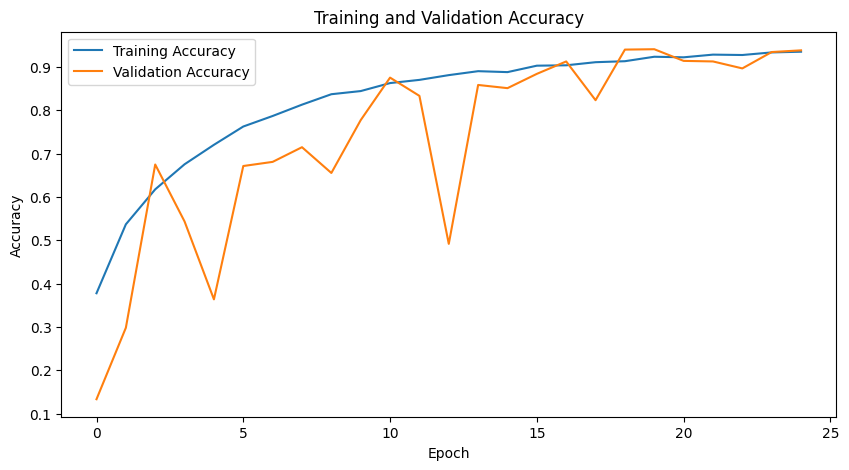

In [ ]:
# PLOT TRAINING AND VALIDATION ACCURACY

# Create a plotting figure
#
# figsize controls the width and height
# of the visualization
plt.figure(figsize=(10, 5))

# PLOT TRAINING ACCURACY

# history.history['accuracy'] contains
# the training accuracy values recorded
# after each epoch during model training
#
# The graph shows how the model performance
# improved on the training dataset over time
plt.plot(

    history.history['accuracy'],

    # Label used in the graph legend
    label='Training Accuracy'
)

# PLOT VALIDATION ACCURACY

# history.history['val_accuracy'] contains
# the validation accuracy values recorded
# after each epoch
#
# Validation accuracy measures how well
# the model performs on unseen validation data
plt.plot(

    history.history['val_accuracy'],

    # Label used in the graph legend
    label='Validation Accuracy'
)

# ADD GRAPH TITLE

# Add descriptive title to the visualization
plt.title(
    'Training and Validation Accuracy'
)

# LABEL GRAPH AXES

# x-axis represents training epochs
plt.xlabel('Epoch')

# y-axis represents accuracy values
plt.ylabel('Accuracy')

# DISPLAY LEGEND

# Show graph legend to distinguish
# training and validation accuracy curves
plt.legend()

# DISPLAY FINAL GRAPH


# Render the visualization
plt.show()

##**Interpretation of Training and Validation Accuracy Graph**

The graph shows that both training accuracy and validation accuracy generally improved as the number of training epochs increased, indicating that the proposed Hybrid CNN-BiGRU with Self-Attention model successfully learned emotional speech patterns from the dataset. The training accuracy steadily increased and eventually exceeded 90%, while the validation accuracy also reached similarly high values, demonstrating strong generalization performance on unseen data.

Although the validation accuracy experienced some fluctuations during certain epochs, the overall trend remained upward and stable throughout training. The close relationship between training and validation accuracy suggests that the model learned effectively without experiencing severe overfitting. By the final epochs, both accuracy curves converged near 94%, indicating that the model achieved stable and consistent performance for Speech Emotion Recognition.

##**Training Loss Visualization**

The following graph visualizes the training and validation loss across epochs.

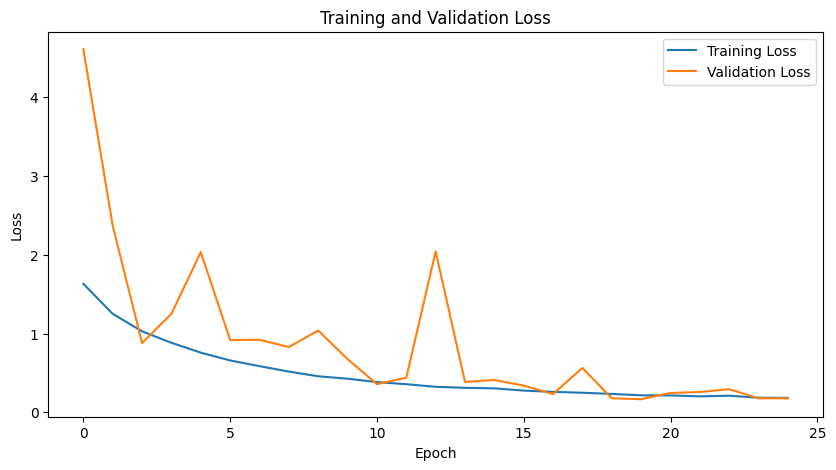

In [ ]:
# PLOT TRAINING AND VALIDATION LOSS

# Create a plotting figure
#
# figsize controls the width and height
# of the visualization
plt.figure(figsize=(10, 5))

# PLOT TRAINING LOSS

# history.history['loss'] contains
# the training loss values recorded
# after each epoch during model training
#
# Loss measures the prediction error
# of the model
#
# Lower loss values indicate
# better model performance
plt.plot(

    history.history['loss'],

    # Label used in the graph legend
    label='Training Loss'
)

# PLOT VALIDATION LOSS

# history.history['val_loss'] contains
# the validation loss values recorded
# after each epoch
#
# Validation loss measures how well
# the model performs on unseen data
#
# Monitoring validation loss helps detect:
# - overfitting
# - underfitting
# - training stability
plt.plot(

    history.history['val_loss'],

    # Label used in the graph legend
    label='Validation Loss'
)

# ADD GRAPH TITLE

# Add descriptive title to the visualization
plt.title(
    'Training and Validation Loss'
)

# LABEL GRAPH AXES

# x-axis represents training epochs
plt.xlabel('Epoch')

# y-axis represents loss values
plt.ylabel('Loss')

# DISPLAY LEGEND

# Show graph legend to distinguish
# training and validation loss curves
plt.legend()

# DISPLAY FINAL GRAPH

# Render the visualization
plt.show()

##**Interpretation of Training and Validation Loss Graph**

The graph shows that both training loss and validation loss generally decreased as training progressed, indicating that the proposed Hybrid CNN-BiGRU with Self-Attention model improved its prediction capability over time. The steady decline in training loss demonstrates that the model successfully learned important emotional speech patterns from the dataset.

Although the validation loss experienced some fluctuations during certain epochs, the overall trend continued to decrease and eventually stabilized at a relatively low value. These temporary spikes may have been caused by variations in validation samples or the complexity of distinguishing similar emotions. However, the validation loss remained close to the training loss throughout most of the training process, suggesting that the model maintained good generalization performance and did not experience severe overfitting.

By the final epochs, both training and validation loss converged near low values, indicating stable learning behavior and effective optimization. Hence, the decreasing loss trends demonstrate that the proposed architecture trained successfully and achieved reliable performance for Speech Emotion Recognition tasks.

# **Training Summary**

The training process demonstrates how the model learns emotional speech patterns over multiple epochs. Accuracy and loss curves provide insight into:
- model convergence
- generalization performance
- possible overfitting or underfitting

EarlyStopping helps improve model stability by restoring the best-performing model weights during training.

# **Evaluation and Testing**

This section evaluates the performance of the proposed Hybrid CNN-BiGRU with Self-Attention model using various evaluation metrics and visualizations. The model is tested on unseen speech emotion samples to assess its classification capability and generalization performance.

##**Model Evaluation Metrics**

The following metrics are used to evaluate model performance:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

These metrics help measure the effectiveness of the model in correctly classifying speech emotions.

### IMPORT EVALUATION METRICS

In [ ]:
# IMPORT EVALUATION METRICS

# Import evaluation metric functions
# from scikit-learn
#
# These metrics are used to evaluate
# the performance of the trained
# Speech Emotion Recognition model
from sklearn.metrics import (

    # CLASSIFICATION REPORT

    # classification_report() generates
    # detailed evaluation metrics including:
    # - precision
    # - recall
    # - F1-score
    # - support
    #
    # for each emotion class
    classification_report,

    # CONFUSION MATRIX

    # confusion_matrix() generates
    # a matrix showing:
    # - correct predictions
    # - incorrect predictions
    #
    # This helps analyze which emotion classes
    # are frequently misclassified
    confusion_matrix
)

##**Generate Predictions**

The following step generates emotion predictions from the testing dataset.

In [ ]:
# GENERATE MODEL PREDICTIONS

# Use the trained model to generate
# prediction probabilities for the testing dataset
#
# model.predict() outputs probability scores
# for all emotion classes
#
# Example output for one sample:
# [0.01, 0.03, 0.80, 0.02, 0.05, 0.04, 0.03, 0.02]
#
# The highest probability represents
# the predicted emotion class
predictions = model.predict(
    X_test
)

# CONVERT PREDICTION PROBABILITIES
# INTO CLASS INDICES

# np.argmax() selects the index
# of the highest probability value
#
# axis=1 means:
# find the highest probability
# across each row/sample
#
# Example:
# [0.01, 0.03, 0.80, 0.02]
#
# becomes:
# 2
predicted_labels = np.argmax(
    predictions,
    axis=1
)

# CONVERT TRUE LABELS
# INTO CLASS INDICES

# y_test is currently one-hot encoded
#
# Example:
# [0, 0, 1, 0, 0, 0, 0, 0]
#
# np.argmax() converts it back
# into its integer label representation
#
# Result:
# 2
true_labels = np.argmax(
    y_test,
    axis=1
)

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step


##**Prediction Generation Interpretation**

The model successfully generated prediction probabilities for the testing dataset and converted them into emotion class labels using the highest probability values for each sample. The true labels were also converted from one-hot encoded format into class indices to enable direct comparison between actual and predicted emotions. This process prepares the model outputs for further evaluation using metrics such as the classification report and confusion matrix.

##**Classification Report**

The classification report displays:
- Precision
- Recall
- F1-Score
- Support

for each emotion class.

In [ ]:
# DISPLAY CLASSIFICATION REPORT

# classification_report() generates
# detailed evaluation metrics for each emotion class
#
# The report includes:
# - Precision
# - Recall
# - F1-score
# - Support
#
# Precision:
# Measures how many predicted samples
# for a class were actually correct
#
# Recall:
# Measures how many actual samples
# of a class were successfully identified
#
# F1-score:
# Harmonic mean of precision and recall
#
# Support:
# Number of true samples for each class
print(

    classification_report(

        # True emotion labels
        true_labels,

        # Predicted emotion labels
        predicted_labels,

        # Display actual emotion names
        # instead of numerical labels
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.96      0.99      0.97       308
        calm       0.95      0.91      0.93       307
     disgust       0.96      0.97      0.97       307
     fearful       0.92      0.95      0.94       307
       happy       0.99      0.92      0.95       307
     neutral       0.89      0.90      0.89       154
         sad       0.92      0.89      0.91       307
   surprised       0.92      0.98      0.95       307

    accuracy                           0.94      2304
   macro avg       0.94      0.94      0.94      2304
weighted avg       0.94      0.94      0.94      2304



##**Classification Report Interpretation**

The classification report shows that the proposed Hybrid CNN-BiGRU with Self-Attention model achieved strong performance across most emotion classes, obtaining an overall accuracy of approximately 94% on the testing dataset. The high precision, recall, and F1-scores indicate that the model was able to correctly classify the majority of speech emotion samples.

Emotions such as angry, disgust, happy, and surprised achieved particularly high scores, demonstrating that the model effectively recognized distinct emotional speech patterns. Meanwhile, emotions such as neutral and sad obtained slightly lower performance metrics, which may be due to overlapping acoustic characteristics and similarities between certain emotional expressions.

Therefore, the classification results demonstrate that the proposed architecture generalized well on unseen data and performed effectively for Speech Emotion Recognition tasks.

##**Confusion Matrix**

The confusion matrix visualizes how well the model correctly classifies each emotion class and identifies possible misclassifications.

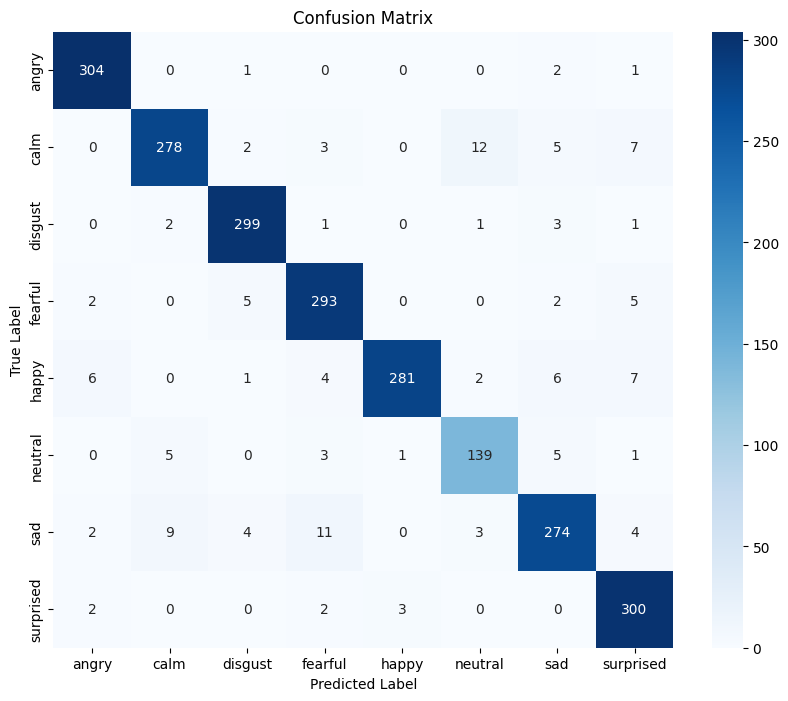

In [ ]:
# COMPUTE CONFUSION MATRIX

# Generate the confusion matrix
#
# confusion_matrix() compares:
# - true emotion labels
# - predicted emotion labels
#
# The confusion matrix helps analyze:
# - correct classifications
# - incorrect classifications
# - commonly confused emotion classes
cm = confusion_matrix(

    # Actual emotion labels
    true_labels,

    # Predicted emotion labels
    predicted_labels
)

# CREATE VISUALIZATION FIGURE

# Create a plotting figure
#
# figsize controls the width and height
# of the visualization
plt.figure(figsize=(10, 8))

# PLOT CONFUSION MATRIX HEATMAP

# sns.heatmap() visualizes the confusion matrix
# using a color-coded grid
sns.heatmap(

    # Confusion matrix values
    cm,

    # Display numerical values inside each cell
    annot=True,

    # Display values as integers
    fmt='d',

    # Use blue color palette
    cmap='Blues',

    # Display emotion labels
    # along the x-axis
    xticklabels=label_encoder.classes_,

    # Display emotion labels
    # along the y-axis
    yticklabels=label_encoder.classes_
)

# ADD GRAPH TITLE

# Add title to describe the visualization
plt.title("Confusion Matrix")

# LABEL GRAPH AXES

# x-axis represents predicted emotion labels
plt.xlabel("Predicted Label")

# y-axis represents true emotion labels
plt.ylabel("True Label")

# DISPLAY FINAL VISUALIZATION

# Render the confusion matrix heatmap
plt.show()

##**Confusion Matrix Interpretation**

The confusion matrix shows that the proposed Hybrid CNN-BiGRU with Self-Attention model correctly classified the majority of speech emotion samples, as indicated by the high values along the diagonal of the matrix. This demonstrates that the model achieved strong recognition performance across most emotion classes.

Emotions such as angry, disgust, fearful, happy, and surprised obtained high correct classification counts, indicating that the model effectively learned distinct emotional speech patterns from the dataset. However, a few misclassifications were still observed between certain emotion classes. For example, some calm samples were predicted as neutral or surprised, while some sad samples were predicted as fearful or calm. These errors may be caused by similarities in acoustic characteristics and overlapping emotional expressions between certain emotions.

Despite these minor misclassifications, the confusion matrix indicates that the model generalized well on unseen data and maintained high classification accuracy across multiple speech emotion categories.

##**Sample Predictions**

The following section displays sample predictions generated by the trained model.

In [ ]:
# DISPLAY SAMPLE PREDICTIONS

# Define the number of prediction examples
# to display from the testing dataset
num_examples = 10

# ITERATE THROUGH SAMPLE PREDICTIONS

# Loop through the selected number of samples
for i in range(num_examples):

    # GET PREDICTED EMOTION LABEL

    # predicted_labels contains numerical
    # prediction indices
    #
    # label_encoder.classes_ converts
    # the numerical index back into
    # its corresponding emotion label
    predicted_emotion = label_encoder.classes_[

        predicted_labels[i]
    ]

    # GET ACTUAL EMOTION LABEL

    # true_labels contains the actual
    # emotion class indices
    #
    # Convert the numerical label
    # back into its original emotion name
    actual_emotion = label_encoder.classes_[

        true_labels[i]
    ]

    # DISPLAY SAMPLE NUMBER

    # Print the current sample number
    print(f"Sample {i+1}")

    # DISPLAY ACTUAL EMOTION

    # Print the true emotion label
    print(
        "Actual Emotion:",
        actual_emotion
    )

    # DISPLAY PREDICTED EMOTION

    # Print the predicted emotion label
    #generated by the trained model
    print(
        "Predicted Emotion:",
        predicted_emotion
    )

    # DISPLAY SEPARATOR

    # Print a separator line
    # for better readability
    print("-" * 40)

Sample 1
Actual Emotion: angry
Predicted Emotion: angry
----------------------------------------
Sample 2
Actual Emotion: angry
Predicted Emotion: angry
----------------------------------------
Sample 3
Actual Emotion: sad
Predicted Emotion: sad
----------------------------------------
Sample 4
Actual Emotion: angry
Predicted Emotion: angry
----------------------------------------
Sample 5
Actual Emotion: angry
Predicted Emotion: angry
----------------------------------------
Sample 6
Actual Emotion: disgust
Predicted Emotion: disgust
----------------------------------------
Sample 7
Actual Emotion: sad
Predicted Emotion: sad
----------------------------------------
Sample 8
Actual Emotion: sad
Predicted Emotion: sad
----------------------------------------
Sample 9
Actual Emotion: surprised
Predicted Emotion: surprised
----------------------------------------
Sample 10
Actual Emotion: surprised
Predicted Emotion: happy
----------------------------------------


##**Sample Prediction Interpretation**

The sample predictions show that the proposed Hybrid CNN-BiGRU with Self-Attention model correctly classified most speech emotion samples from the testing dataset. The majority of the predicted emotions matched the actual emotion labels, indicating that the model effectively learned emotional speech patterns and achieved strong recognition performance.

A few misclassifications were still observed, such as predicting a surprised emotion as happy. This may occur because certain emotions share similar acoustic characteristics, including tone, pitch, and speech intensity, making them more difficult to distinguish accurately. Despite these minor errors, the overall prediction results demonstrate that the model generalized well and performed effectively for Speech Emotion Recognition tasks.

##**Error Analysis**

Error analysis helps identify emotion classes that are difficult for the model to distinguish. Misclassifications may occur because some emotions share similar acoustic characteristics.

Examples:
- Calm and Neutral
- Fearful and Surprised
- Sad and Calm

Understanding these errors helps improve future model performance and architecture design.

##**Comparison with Existing Models**

The proposed Hybrid CNN-BiGRU with Self-Attention model can be compared with previous Speech Emotion Recognition architectures such as:

- CNN-only models
- LSTM-based models
- CNN-BiLSTM models
- CNN-BiLSTM with Attention models

The proposed model aims to:
- reduce computational complexity using BiGRU
- improve focus on emotional speech segments using Self-Attention
- enhance feature representation using MFCC and Mel Spectrogram features

##**Evaluation Summary**

The evaluation results demonstrate the effectiveness of the proposed Hybrid CNN-BiGRU with Self-Attention model in recognizing emotions from speech signals. The confusion matrix, classification report, and sample predictions provide insight into the model’s overall performance, strengths, and limitations.

The proposed architecture successfully combines:
- acoustic feature extraction through CNN layers
- temporal sequence learning using BiGRU
- attention-based contextual understanding through the Self-Attention mechanism

These components work together to improve Speech Emotion Recognition performance by effectively capturing important acoustic and sequential emotional patterns from speech audio data.

#**Reflection and Insights**

This section discusses the lessons learned, challenges encountered during implementation, possible future improvements, and the ethical and societal implications of Speech Emotion Recognition systems.

## **Lessons Learned**

Throughout this project, several important insights about deep learning and Speech Emotion Recognition (SER) were gained. The development of the proposed Hybrid CNN-BiGRU with Self-Attention model demonstrated how multiple deep learning components can work together within a hybrid architecture to improve speech emotion classification performance. The CNN layers effectively extracted local acoustic and spectral features from audio signals, while the BiGRU layer successfully captured temporal dependencies and contextual information from speech sequences. In addition, the Self-Attention mechanism enabled the model to focus on emotionally important speech segments, highlighting the importance of combining spatial, sequential, and contextual learning mechanisms for complex audio classification tasks.

The project also emphasized the significance of feature engineering in Speech Emotion Recognition. Audio feature extraction techniques such as MFCC and Mel Spectrogram features played a major role in improving the model’s ability to capture emotional characteristics from speech signals. Combining these features provided richer and more informative audio representations, which contributed to improved model performance. Furthermore, data augmentation techniques including noise injection, pitch shifting, and time stretching helped improve model robustness and generalization by increasing dataset diversity and reducing overfitting.

Another important lesson learned was the value of proper model regularization techniques. Methods such as Dropout, Batch Normalization, and EarlyStopping were essential in stabilizing the training process, preventing overfitting, and improving overall model generalization performance. To sum up, the project provided deeper insight into deep learning architectures, audio preprocessing, feature extraction, model optimization, and the practical challenges involved in developing effective Speech Emotion Recognition systems.

## **Challenges Encountered**

Several technical and implementation challenges were encountered during the development of the proposed Hybrid CNN-BiGRU with Self-Attention model for Speech Emotion Recognition. One of the primary challenges involved feature dimension mismatches caused by combining MFCC and Mel Spectrogram features. Since the combined feature representations produced different input dimensions compared to the original MFCC-only setup, input shape mismatch errors initially occurred during model training and required modifications to the preprocessing pipeline and model architecture.

Another major challenge was the computational complexity of the project. Training a hybrid deep learning model with multiple layers, combined audio features, and data augmentation techniques required significant computational resources and longer training times, particularly when processing augmented speech samples and large feature matrices. Managing memory usage and maintaining stable execution within the Google Colab environment also became important considerations throughout implementation.

Emotion similarity also posed difficulties during classification. Certain emotions shared highly similar acoustic and speech characteristics, making them more difficult for the model to distinguish accurately. Examples included calm versus neutral, fearful versus surprised, and sad versus calm emotions. These similarities occasionally resulted in misclassifications and reduced prediction confidence for specific emotion classes.

In addition, several debugging and implementation issues were encountered throughout the project, including TensorFlow import errors, undefined model variables, preprocessing inconsistencies, and input dimension mismatches. Addressing these problems required careful troubleshooting, proper sequential execution of notebook cells, and continuous verification of preprocessing and model configurations. Despite these challenges, resolving these issues contributed to a deeper understanding of deep learning workflows, audio preprocessing pipelines, and Speech Emotion Recognition system development.

##**Possible Improvements**

Several improvements may further enhance the performance, robustness, and generalization capability of the proposed Hybrid CNN-BiGRU with Self-Attention model for Speech Emotion Recognition. One possible enhancement is the use of more advanced attention mechanisms, such as Multi-Head Self-Attention or Transformer-based Attention, which may improve the model’s ability to capture long-range contextual dependencies and complex emotional patterns within speech sequences.

Additional feature fusion techniques may also improve emotional representation by incorporating other audio features such as Chroma Features, Spectral Contrast, and Tonnetz Features alongside MFCC and Mel Spectrogram features. These additional representations may help the model capture richer acoustic and harmonic information from speech signals.

Future experiments may also focus on hyperparameter optimization, including adjustments to learning rate, batch size, number of GRU units, dropout rates, and the number of CNN filters. Optimizing these parameters may further improve model accuracy, convergence speed, and overall training stability.

Another possible improvement involves training the model on larger and more diverse datasets, including multilingual speech datasets, real-world noisy audio recordings, and larger Speech Emotion Recognition corpora. This may improve the model’s ability to generalize across different speakers, languages, accents, and recording environments.

Finally, future implementations may focus on real-time deployment of the proposed model in practical applications such as mobile systems, intelligent virtual assistants, healthcare monitoring systems, and emotion-aware human-computer interaction platforms.

## **Ethical and Societal Implications**

Speech Emotion Recognition (SER) systems can provide significant benefits to society, particularly in areas such as human-computer interaction, healthcare monitoring, mental health support, educational technologies, and customer service systems. By enabling machines to recognize and respond to human emotions, emotion-aware systems can create more adaptive, intelligent, and personalized interactions. However, despite these advantages, SER systems also raise important ethical and societal concerns that must be carefully addressed.

Speech recordings may contain sensitive personal information, and improper handling of voice data may lead to privacy risks, data security issues, or unauthorized monitoring. For this reason, proper user consent, responsible data collection practices, and secure storage of audio recordings are essential when developing and deploying SER systems.

In addition, speech emotion datasets may not fully represent different accents, languages, age groups, and cultural speaking styles, which may introduce bias and reduce fairness across diverse populations. Human emotions are also highly subjective and complex, meaning that incorrect emotion predictions may result in misunderstandings, inappropriate automated responses, or excessive reliance on artificial intelligence systems.

Because of these concerns, Speech Emotion Recognition technologies should assist human decision-making rather than completely replace human emotional understanding. Developers and researchers must ensure that these systems are transparent, fair, privacy-aware, ethically deployed, and socially responsible in order to minimize potential risks and promote trustworthy AI applications.

##**References**

## Papers

1. Vaswani, A., et al. (2017). *Attention Is All You Need*. Advances in Neural Information Processing Systems (NeurIPS).  
Link: https://arxiv.org/pdf/1706.03762

2. Cho, K., et al. (2014). *Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation*. EMNLP Conference.  
Link: https://arxiv.org/pdf/1406.1078

3. Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation.  
Link: https://www.bioinf.jku.at/publications/older/2604.pdf

4. Livingstone, S. R., & Russo, F. A. (2018). *The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS)*. PLoS ONE.  
Link: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0196391

---

## Dataset

5. RAVDESS Emotional Speech Audio Dataset  
Link: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio

---

## Documentation and Libraries

6. TensorFlow Keras Documentation  
Link: https://www.tensorflow.org/api_docs

7. Librosa Documentation  
Link: https://librosa.org/doc/latest/index.html

8. Scikit-learn Documentation  
Link: https://scikit-learn.org/stable/documentation.html

---

## Development Environment

9. Google Colab Documentation  
Link: https://colab.research.google.com/